# 🤖 AI Jobs Market 2025–2026 — Salary Analysis & Job Recommender

> **End-to-end data pipeline:** EDA → Feature Engineering → Salary Insights → Cosine-Similarity Recommender

---

## 📌 Project Overview

This notebook performs a full analysis of the **AI Jobs Market (2025–2026)** dataset and builds a **job recommender system** powered by skill-based cosine similarity.

### What This Notebook Covers
| Phase | Description |
|---|---|
| **1. Setup & Data Loading** | Imports, config, raw data preview |
| **2. EDA** | Shape, nulls, duplicates, distributions, correlations |
| **3. Hypothesis-Driven Analysis** | 5 hypotheses tested with charts and key takeaways |
| **4. Category Deep-Dives** | AI Engineering & Data Science breakdowns |
| **5. Feature Engineering** | Skill binary columns, merge variants, cleaned CSV export |
| **6. Recommender System** | Cosine similarity on skill profiles → job recommendations |

---

## 🔑 Key Takeaways (Read Before Running)

1. **`experience_level` (job title tier) is the #1 salary predictor** — stronger than raw `years_of_experience`
2. **Python appears in 62.8% of all jobs** — the single most essential skill
3. **System Design ($249k) & Prompt Engineering ($247k)** pay the most despite low frequency — scarcity drives price
4. **Remote work has negligible salary impact** — only a 2.7% variance across all work modes
5. **6–9 year bracket dominates hiring** — 45–50% of all postings regardless of company size
6. **The recommender uses cosine similarity on skill binary vectors** — grouped by job title profiles

---

## 📁 Expected Folder Structure

```
/kaggle/working/
├── ai_jobs_market_2025_2026.csv   ← input dataset (attach to notebook)
```

> **Note:** The Feature Engineering step (Phase 5) writes `cleaned_data.csv` to `/kaggle/working/` automatically.

---

## ⚙️ Dependencies

All libraries are pre-installed in the Kaggle environment. No `pip install` required.


## Phase 1 — Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.metrics.pairwise import cosine_similarity

# ── Display config ──────────────────────────────────────────────
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

# ── Load dataset ────────────────────────────────────────────────
# Kaggle path — dataset must be attached to the notebook session


df = pd.read_csv("../data/ai_jobs_market_2025_2026.csv")
df.drop(columns="job_id", inplace=True)

print(f" Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(5)

✅ Dataset loaded: 1,500 rows × 24 columns


,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,country,remote_work,company_size,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,USA,On-site,Startup (1-50),Finance,APIs|Planning Systems|Python|Cloud|SQL|Leadership,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,UK,Hybrid,Enterprise (5000+),Finance,Python|Documentation|LLM APIs|Prompt Design|NLP|Testing|Cloud,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,USA,Fully Remote,Big Tech (FAANG+),Finance,Vector DBs|Python|Prompt Engineering|Fine-tuning|Agile,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,Singapore,Fully Remote,SME (51-500),Technology,Feature Stores|Spark|ETL|Airflow|dbt|SQL|Python|Statistics|SQL|Communication,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,USA,Fully Remote,Enterprise (5000+),Automotive,Data Analysis|Stakeholder Mgmt|Agile|Cloud|Problem Solving|Statistics,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


## Phase 2 — Exploratory Data Analysis

### 2.1 Data Quality Check

In [2]:
# Duplicates, shape, and null check
print(f"Duplicates     : {df.duplicated().sum()}")
print(f"Shape          : {df.shape}")
print(f"Total nulls    : {df.isnull().sum().sum()}")
print()
print(df.info())

Duplicates     : 0
Shape          : (1500, 24)
Total nulls    : 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_title              1500 non-null   object 
 1   job_category           1500 non-null   object 
 2   experience_level       1500 non-null   object 
 3   years_of_experience    1500 non-null   int64  
 4   education_required     1500 non-null   object 
 5   annual_salary_usd      1500 non-null   float64
 6   salary_min_usd         1500 non-null   int64  
 7   salary_max_usd         1500 non-null   int64  
 8   city                   1500 non-null   object 
 9   country                1500 non-null   object 
 10  remote_work            1500 non-null   object 
 11  company_size           1500 non-null   object 
 12  industry               1500 non-null   object 
 13  required_skills        1500 non-null   ob

In [ ]:
# Statistical summary 
df.describe().round(2)

,years_of_experience,annual_salary_usd,salary_min_usd,salary_max_usd,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role
count,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.0,1500.00,1500.00,1500.0,1500.00,1500.00
mean,6.22,194892.00,135448.67,257537.33,10.86,87.52,31.12,7.9,2025.58,3.97,0.5,0.75,0.22
std,2.68,66506.82,24448.95,39852.82,4.03,8.03,22.05,1.1,0.49,3.27,0.5,0.43,0.41
min,1.00,90000.00,90000.00,180000.00,3.00,68.00,5.00,6.0,2025.00,1.00,0.0,0.00,0.00
25%,4.00,144750.00,120000.00,218000.00,8.20,82.00,15.38,6.9,2025.00,2.00,0.0,1.00,0.00
50%,6.00,180000.00,140000.00,270000.00,10.50,89.00,23.40,7.9,2026.00,3.00,0.0,1.00,0.00
75%,8.00,236250.00,155000.00,290000.00,14.20,95.00,42.70,8.9,2026.00,5.00,1.0,1.00,0.00
max,15.00,384000.00,180000.00,320000.00,18.00,98.00,87.80,9.8,2026.00,12.00,1.0,1.00,1.00


### 2.2 Salary by Job Category & Average Experience Required

In [4]:
round(
    df.groupby("job_category")[["years_of_experience", "annual_salary_usd"]]
    .mean(), 2
).sort_values(by="annual_salary_usd", ascending=False)

,years_of_experience,annual_salary_usd
job_category,,
Architecture,10.35,251576.92
AI Engineering,5.59,207982.34
Infrastructure,5.98,203527.27
Security,6.54,200400.00
ML Operations,6.25,199215.69
Product,7.23,194571.43
Research,8.22,192280.00
Data Science,6.84,181275.59
Data Engineering,5.22,176156.86


### 2.3 Remote Work Distribution & Salary Impact

In [5]:
print(df["remote_work"].value_counts())
print()
round(df.groupby("remote_work")["annual_salary_usd"].agg("mean"), 2)

remote_work
Hybrid          686
Fully Remote    445
On-site         369
Name: count, dtype: int64



remote_work
Fully Remote    197967.19
Hybrid          192694.46
On-site         195268.83
Name: annual_salary_usd, dtype: float64

### Workforce Composition
The data reflects a modern, flexible workforce where 75.4% of employees work in a non-traditional office setting.
1. **Hybrid:** 45.7% (Majority)
2. **Fully Remote:** 29.7%
3. **On-site:** 24.6%

### Salary Finding
Remote work has a negligible impact on compensation — the variance between highest and lowest average salary across work modes is only **2.7%**. Flexibility comes at no salary cost.


### 2.4 Experience Level vs Raw Years — Salary Signal

In [6]:
# experience_level (job-assigned tier) vs years_of_experience (raw tenure)
print("── By experience_level (job tier) ──")
print(df.groupby("experience_level")["annual_salary_usd"].mean().sort_values(ascending=False).round(2))
print()
print("── By years_of_experience (raw tenure) ──")
print(df.groupby("years_of_experience")["annual_salary_usd"].mean().round(2))

── By experience_level (job tier) ──
experience_level
Lead (10+ yrs)      240055.12
Senior (6-9 yrs)    214280.22
Mid (3-5 yrs)       175983.78
Entry (0-2 yrs)     150038.96
Name: annual_salary_usd, dtype: float64

── By years_of_experience (raw tenure) ──
years_of_experience
1     135416.67
2     184202.02
3     191632.53
4     195548.19
5     191025.84
6     196006.73
7     199464.97
8     196242.53
9     199996.67
10    179965.31
11    224580.00
12    222475.68
13    277500.00
14    204000.00
15    181200.00
Name: annual_salary_usd, dtype: float64


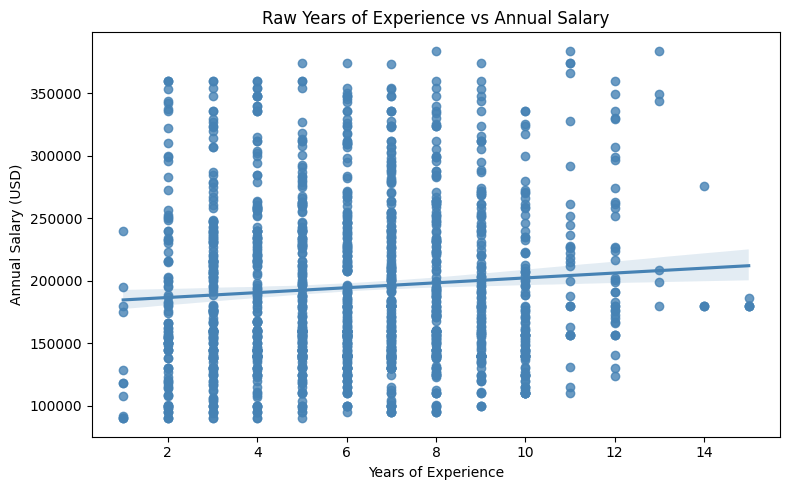

In [7]:
# Regression plot: raw years vs salary
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="years_of_experience", y="annual_salary_usd", color="steelblue")
plt.title("Raw Years of Experience vs Annual Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Annual Salary (USD)")
plt.tight_layout()
plt.show()

### 2.5 Feature Correlation with Salary

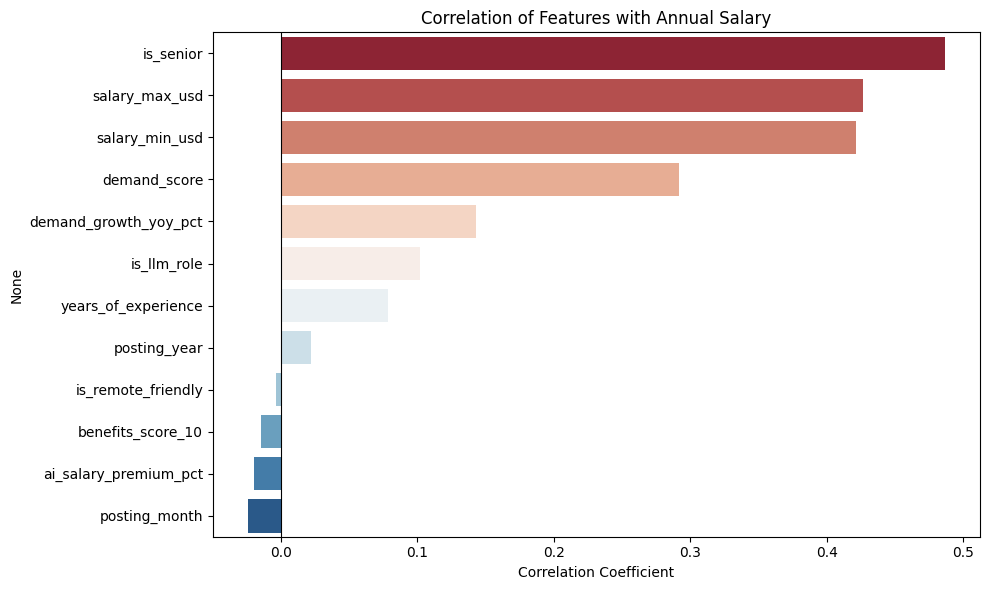

In [8]:
corr_matrix = df.corr(numeric_only=True)
salary_corr = corr_matrix["annual_salary_usd"].sort_values(ascending=False).drop("annual_salary_usd")

plt.figure(figsize=(10, 6))
sns.barplot(x=salary_corr.values, y=salary_corr.index, palette="RdBu")
plt.title("Correlation of Features with Annual Salary")
plt.xlabel("Correlation Coefficient")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

### 📊 Top 4 Strategic Insights from Correlation Analysis

- **Seniority over Tenure:** `is_senior` is the strongest salary predictor — organizational level matters more than raw tenure.
- **Market Dynamics:** High `demand_score` and `demand_growth_yoy` drive salaries — specialized scarcity pushes compensation higher than role labels like `is_llm_role`.
- **The Premium Paradox:** `ai_salary_premium_pct` has a slight negative correlation — entry-level roles get the biggest % raises, but top *absolute* salaries stay in senior brackets.
- **Seasonal & Flexibility Neutrality:** `is_remote_friendly` and `benefits_score` show near-zero correlation with salary — prioritize flexibility without sacrificing pay.


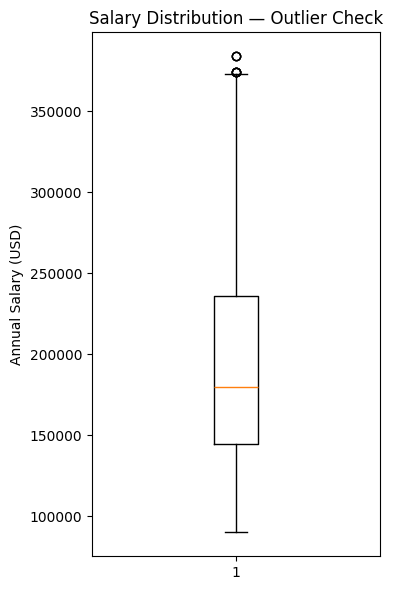

In [9]:
# Salary outlier check
plt.figure(figsize=(4, 6))
plt.boxplot(df["annual_salary_usd"])
plt.title("Salary Distribution — Outlier Check")
plt.ylabel("Annual Salary (USD)")
plt.tight_layout()
plt.show()

## Phase 3 — Hypothesis-Driven Analysis

---

### Hypothesis 1
> The most in-demand skills will **not** necessarily be the highest paying — high demand reflects baseline requirements (Python, SQL), while specialized skills (Cloud, Leadership) command salary premiums despite lower frequency.


In [10]:
# Build skills_exploded for all hypothesis analysis in this phase
df["skills_list"] = df["required_skills"].str.split("|")
skills_exploded = df.explode("skills_list")
skills_exploded["skills_list"] = skills_exploded["skills_list"].str.strip()

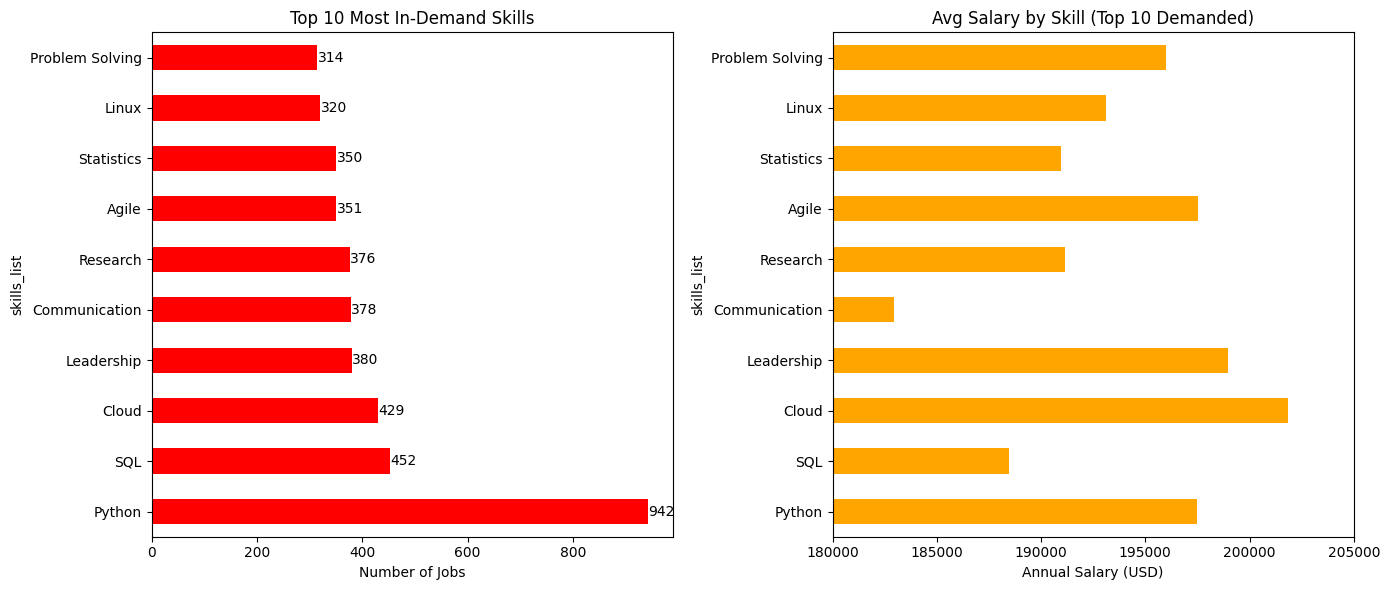

                 count  count_pct
skills_list                      
Python             942       62.8
SQL                452       30.1
Cloud              429       28.6
Leadership         380       25.3
Communication      378       25.2
Research           376       25.1
Agile              351       23.4
Statistics         350       23.3
Linux              320       21.3
Problem Solving    314       20.9


In [11]:
# Top 10 most in-demand skills — demand vs avg salary
result = round(
    skills_exploded.groupby("skills_list")["annual_salary_usd"]
    .agg(["count", "mean"])
    .sort_values(by="count", ascending=False)
    .head(10), 2
)
result["count_pct"] = round((result["count"] / len(df)) * 100, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

result["count"].plot(kind="barh", ax=axes[0], color="red")
axes[0].set_title("Top 10 Most In-Demand Skills")
axes[0].set_xlabel("Number of Jobs")
for i, v in enumerate(result["count"]):
    axes[0].text(v + 1, i, str(int(v)), va="center")

result["mean"].plot(kind="barh", ax=axes[1], color="orange")
axes[1].set_title("Avg Salary by Skill (Top 10 Demanded)")
axes[1].set_xlabel("Annual Salary (USD)")
axes[1].set_xlim(180000, 205000)

plt.tight_layout()
plt.show()

print(result[["count", "count_pct"]].sort_values(by="count", ascending=False))

### ✅ Key Takeaways — Hypothesis 1 Confirmed

**Chart 1 — Top 10 Most In-Demand Skills**
- **Python** dominates with 942 jobs (62.8%) — appears in nearly 2 out of 3 postings
- **SQL + Cloud** together cover ~59% of jobs — the expected core technical stack
- **Soft skills (Communication, Leadership, Research)** appear in ~25% of jobs — technical alone isn't enough
- The gap is extreme: Python (942) vs Problem Solving (314) — **3x difference**

**Chart 2 — Avg Salary by Skill**
- **Cloud pays the most (~$203k)** despite not being #1 in demand — **scarcity drives price**
- **Communication pays the least (~$128k)** — only skill below $180k, soft skills alone don't pay well
- **Python pays ~$197k** — high demand AND high salary, single most valuable skill to learn
- **SQL is underpaid** — 2nd most required but near-bottom in salary; it's a commodity

**Skill Tiers:**
| Tier | Skills | Salary |
|---|---|---|
| 💰 Premium | Cloud, Leadership, Agile | $195k+ |
| ✅ Baseline | Python, SQL, Statistics | Required but competitive |
| ⚠️ Commodity | Communication, Problem Solving | Expected but don't boost salary |


---
### Hypothesis 2
> Rare, specialized AI skills (System Design, Prompt Engineering, RAG) will command **higher average salaries** than common baseline skills — scarcity in a fast-growing market should drive a premium independent of posting frequency.


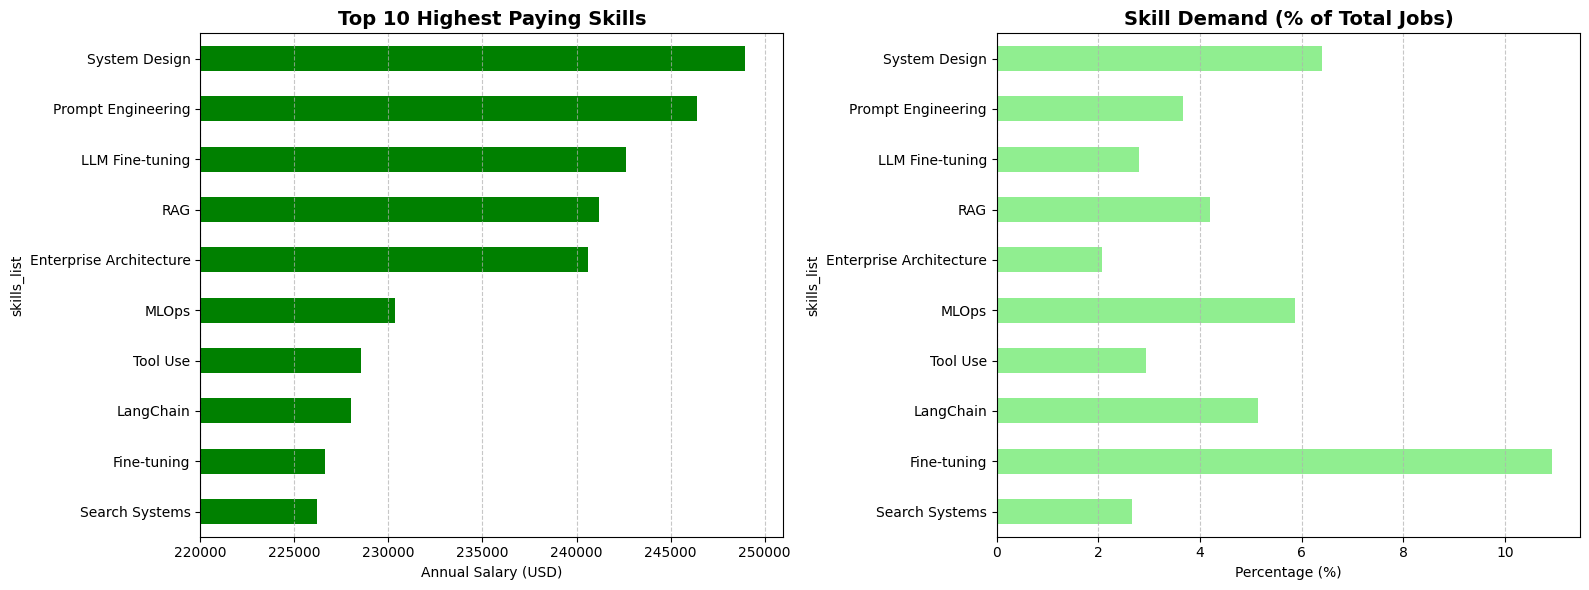

                         count       mean  demand_pct
skills_list                                          
Search Systems              40  226225.00        2.67
Fine-tuning                164  226628.05       10.93
LangChain                   77  227987.01        5.13
Tool Use                    44  228568.18        2.93
MLOps                       88  230352.27        5.87
Enterprise Architecture     31  240612.90        2.07
RAG                         63  241190.48        4.20
LLM Fine-tuning             42  242633.33        2.80
Prompt Engineering          55  246381.82        3.67
System Design               96  248947.92        6.40


In [12]:
# Top 10 highest paying skills vs their demand %
result_pay = round(
    skills_exploded.groupby("skills_list")["annual_salary_usd"]
    .agg(["count", "mean"])
    .sort_values(by="mean", ascending=False)
    .head(10), 2
)
result_sorted = result_pay.sort_values(by="mean", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

result_sorted["mean"].plot(kind="barh", color="Green", ax=axes[0])
axes[0].set_title("Top 10 Highest Paying Skills", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Annual Salary (USD)")
axes[0].set_xlim(220000, 251000)
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

demand_pct = (result_sorted["count"] / len(df)) * 100
demand_pct.plot(kind="barh", color="lightgreen", ax=axes[1])
axes[1].set_title("Skill Demand (% of Total Jobs)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Percentage (%)")
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print(result_sorted[["count", "mean"]].assign(demand_pct=demand_pct.round(2)))

### ✅ Key Takeaways — Hypothesis 2 Confirmed

- **System Design pays the most (~$249k)** — appears in only 6.4% of jobs; rarest = most expensive
- **Prompt Engineering is #2 (~$247k)** — new skill already commanding near-top salary
- **LLM Fine-tuning, RAG, Enterprise Architecture** cluster around **$240–244k** — the core senior AI engineer skillset
- **Salary gap:** Top 5 skills ($240k+) vs bottom 5 ($222–229k) — **~$20k difference** from skill choice alone

> 💡 **Scarcity drives salary.** The highest paying skills are all relatively rare. Learning System Design, Prompt Engineering, or RAG places you in the **$240k+ tier with less competition**.


---
### Hypothesis 3
> Job-assigned `experience_level` will show a **stronger, more consistent** relationship with salary than raw `years_of_experience`, since companies price roles by negotiated title/band rather than tenure alone.


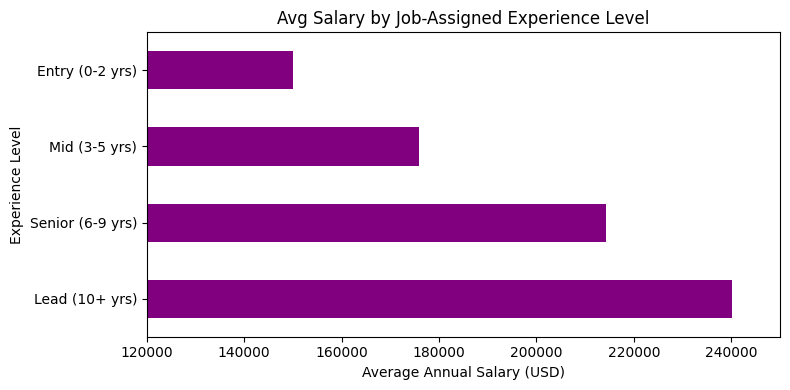

In [13]:
# experience_level bar chart
ct = df.groupby("experience_level")["annual_salary_usd"].mean().sort_values(ascending=False)
ct.plot(kind="barh", color="purple", figsize=(8, 4))
plt.ylabel("Experience Level")
plt.xlabel("Average Annual Salary (USD)")
plt.title("Avg Salary by Job-Assigned Experience Level")
plt.xlim(120000, 250000)
plt.tight_layout()
plt.show()

### ✅ Key Takeaways — Hypothesis 3 Confirmed

| Experience Level | Avg. Annual Salary (USD) |
|---|---|
| Entry (0-2 yrs)  | ~$150,000 |
| Mid (3-5 yrs)    | ~$176,000 |
| Senior (6-9 yrs) | ~$214,000 |
| Lead (10+ yrs)   | ~$240,000 |

Unlike raw `years_of_experience` (which plateaus after year 2), `experience_level` shows a clean, near-linear progression — a **~60% salary increase** from Entry to Lead.

**Bottom line:** Companies pay for the assigned role tier, not tenure. Career growth in this market is about reaching the next *level*, not accumulating years.


---
### Hypothesis 4
> Experience bracket distribution will vary by company size — startups will favour more experienced hires while large enterprises spread hiring across junior and mid-level roles.


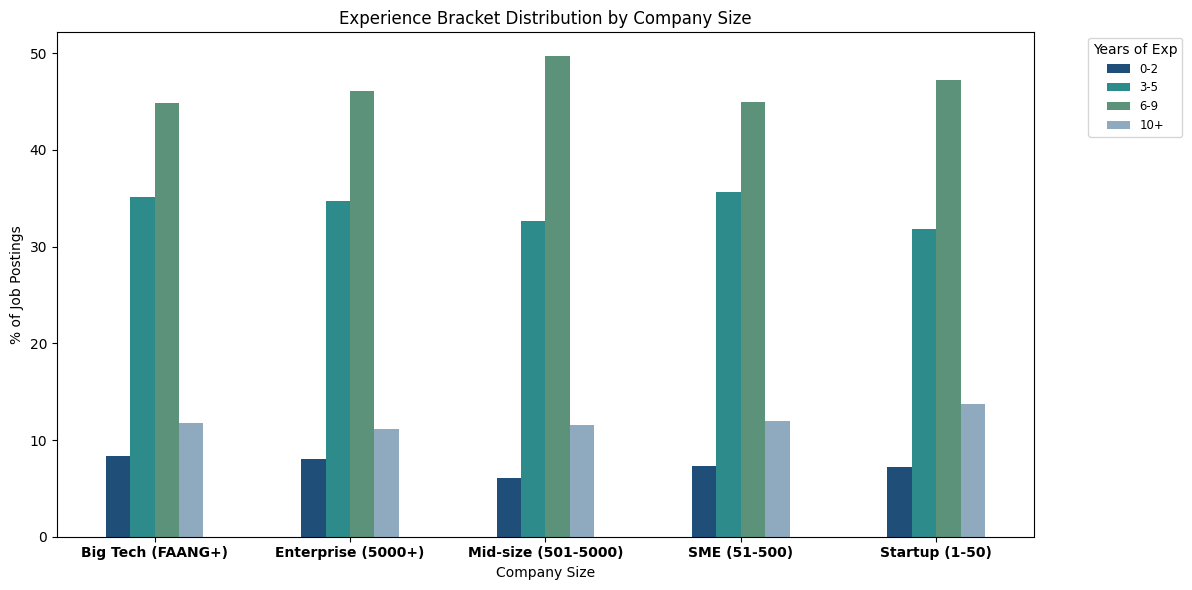

In [14]:
df["exp_bin"] = pd.cut(
    df["years_of_experience"],
    bins=[0, 2, 5, 9, 15],
    labels=["0-2", "3-5", "6-9", "10+"]
)

ct = round(pd.crosstab(df["company_size"], df["exp_bin"], normalize="index") * 100, 2)

ct.plot(kind="bar", figsize=(12, 6), color=["#1f4e79", "#2e8b8b", "#5b9279", "#8faabf"])
plt.title("Experience Bracket Distribution by Company Size")
plt.ylabel("% of Job Postings")
plt.xlabel("Company Size")
plt.xticks(rotation=0, fontweight="bold")
plt.legend(title="Years of Exp", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

### ✅ Key Takeaways — Hypothesis 4 Partially Confirmed

- **The 6–9 Year bracket dominates** all company sizes — 45%–50% of all postings
- **Entry-Level (0–2 yrs) is restricted everywhere** — less than 10% of the market; this is the "fresher gap"
- **Startup veteran bias confirmed:** Startups (1–50) lead all categories in 10+ year roles
- **Mid-size companies (501–5000)** are the most aggressive hirers at the 6–9 bracket, peaking at ~50%
- The bulk of hiring (75–80%) targets professionals with **3–9 years** — mid to senior is the sweet spot


## Phase 4 — Category Deep Dives

### 4.1 Job Category Distribution

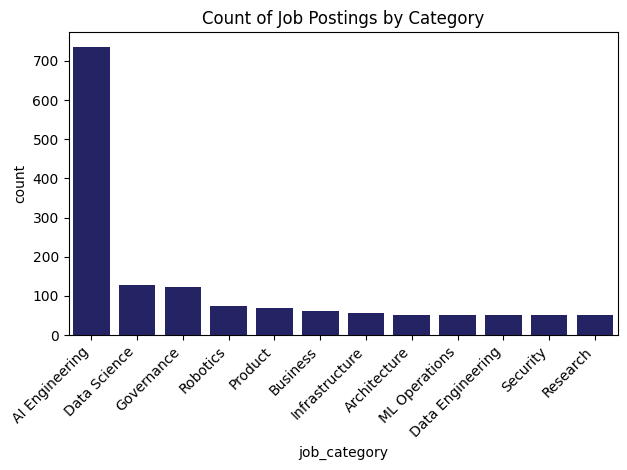

In [15]:
sns.countplot(
    data=df,
    x="job_category",
    color="midnightblue",
    order=df["job_category"].value_counts().index
)
plt.xticks(rotation=45, ha="right")
plt.title("Count of Job Postings by Category")
plt.tight_layout()
plt.show()

### 4.2 AI Engineering Deep Dive

In [16]:
temp_df = df[df["job_category"] == "AI Engineering"]

# Top 5 highest paying AI Engineering roles
print("Top 5 Highest Paying AI Engineering Roles:")
print(round(temp_df.groupby("job_title")["annual_salary_usd"].mean().sort_values(ascending=False), 2).head(5))

Top 5 Highest Paying AI Engineering Roles:
job_title
Senior ML Engineer        247953.12
LLM Engineer              240960.00
AI Agent Developer        225649.12
Multimodal AI Engineer    221791.04
RAG Engineer              218226.42
Name: annual_salary_usd, dtype: float64


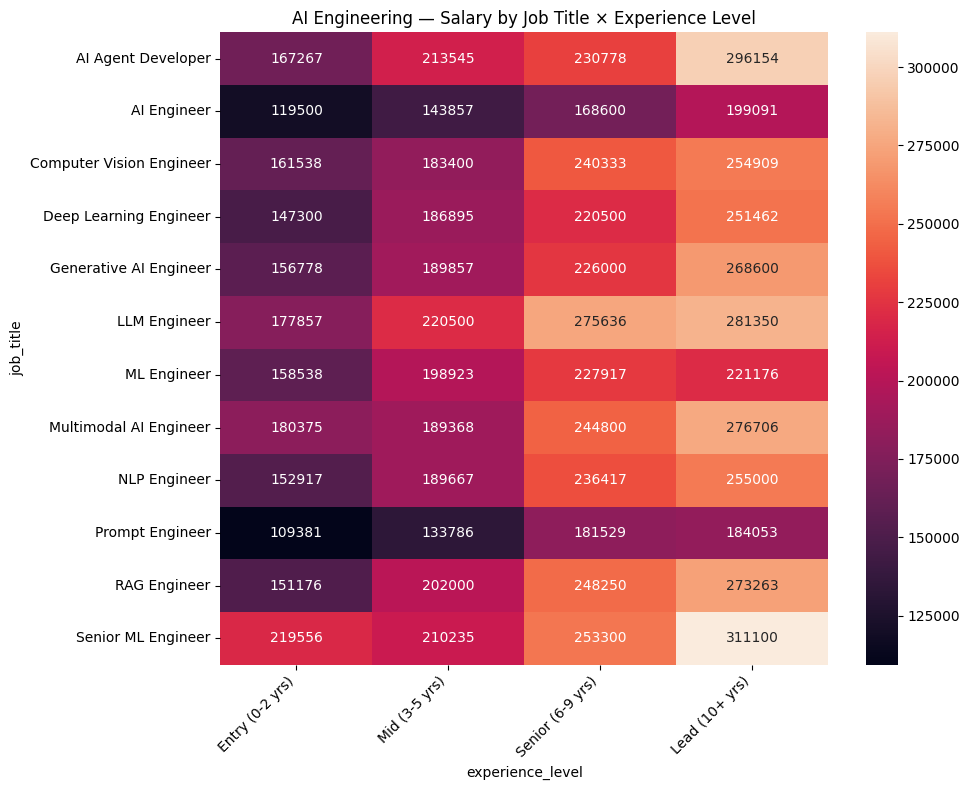

In [17]:
# Salary heatmap: job title × experience level
pivot_df = temp_df.pivot_table(
    index="job_title",
    columns="experience_level",
    values="annual_salary_usd",
    aggfunc="mean"
)
column_order = ["Entry (0-2 yrs)", "Mid (3-5 yrs)", "Senior (6-9 yrs)", "Lead (10+ yrs)"]
pivot_df = pivot_df.reindex(columns=column_order).round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_df, annot=True, cmap="rocket", fmt=".0f")
plt.title("AI Engineering — Salary by Job Title × Experience Level")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 📊 AI Engineering Insights

- **Clear Seniority Premium:** Compensation scales predictably across all AI domains from entry to lead
- **Peak market:** Lead-level Senior ML Engineers and AI Agent Developers top the market at $310k and $300k
- **The $250k Senior Threshold:** Reaching Senior (6–9 yrs) is the standard catalyst to break into $240k–$250k+
- **Lower Bound Roles:** AI Engineers and Prompt Engineers consistently anchor the bottom at ~$110k–$120k entry


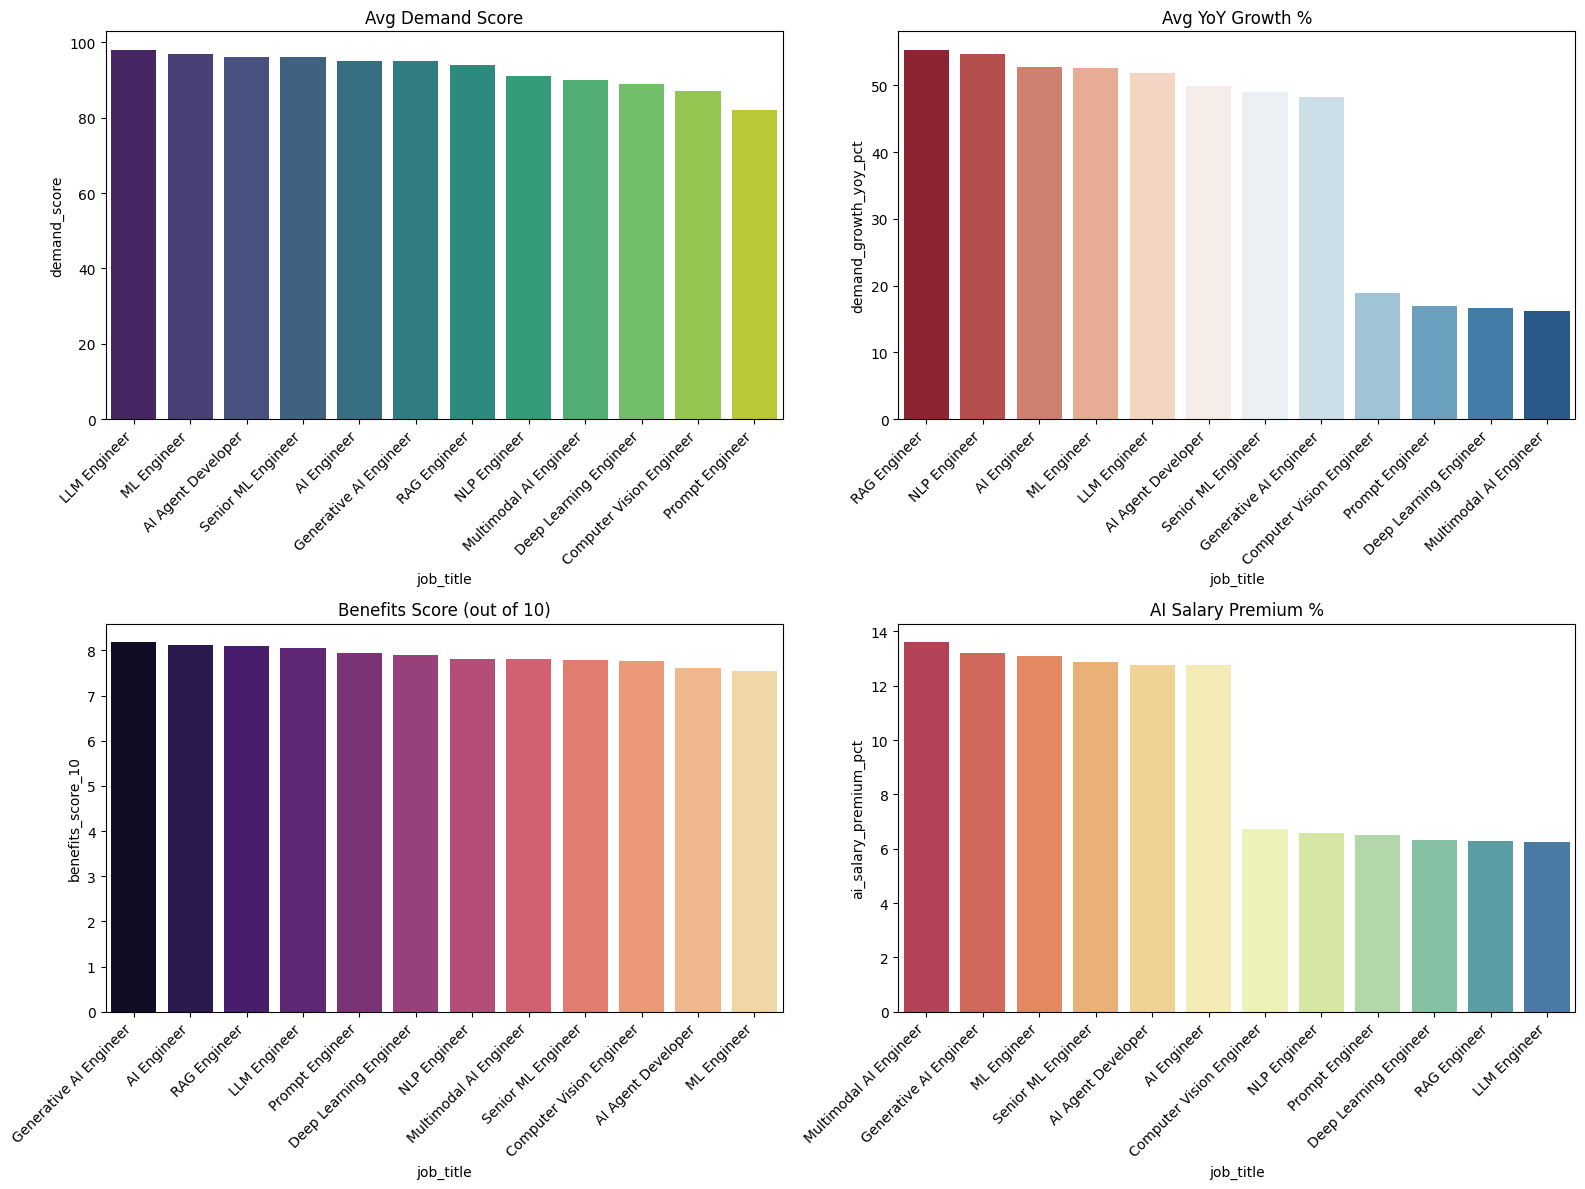

In [18]:
# Demand, growth, benefits & AI premium across AI Engineering roles
x = temp_df.groupby("job_title")[["demand_score", "demand_growth_yoy_pct", "benefits_score_10", "ai_salary_premium_pct"]].mean().round(2)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, col, pal, title in zip(
    axes.flatten(),
    ["demand_score", "demand_growth_yoy_pct", "benefits_score_10", "ai_salary_premium_pct"],
    ["viridis", "RdBu", "magma", "Spectral"],
    ["Avg Demand Score", "Avg YoY Growth %", "Benefits Score (out of 10)", "AI Salary Premium %"]
):
    sorted_x = x.sort_values(by=col, ascending=False)
    sns.barplot(data=sorted_x, x=sorted_x.index, y=col, palette=pal, ax=ax)
    ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

### 📊 AI Engineering Market Dynamics

- **High Demand Stability:** LLM Engineer and ML Engineer maintain the highest absolute demand scores
- **Aggressive Growth:** RAG Engineer and NLP Engineer show the fastest YoY acceleration despite lower base demand
- **Perks Compensation:** Generative AI Engineer and AI Engineer receive top-tier benefits packages
- **AI Agent Developer Bottleneck:** 3rd in demand + high growth + low benefits = highest competitive friction point


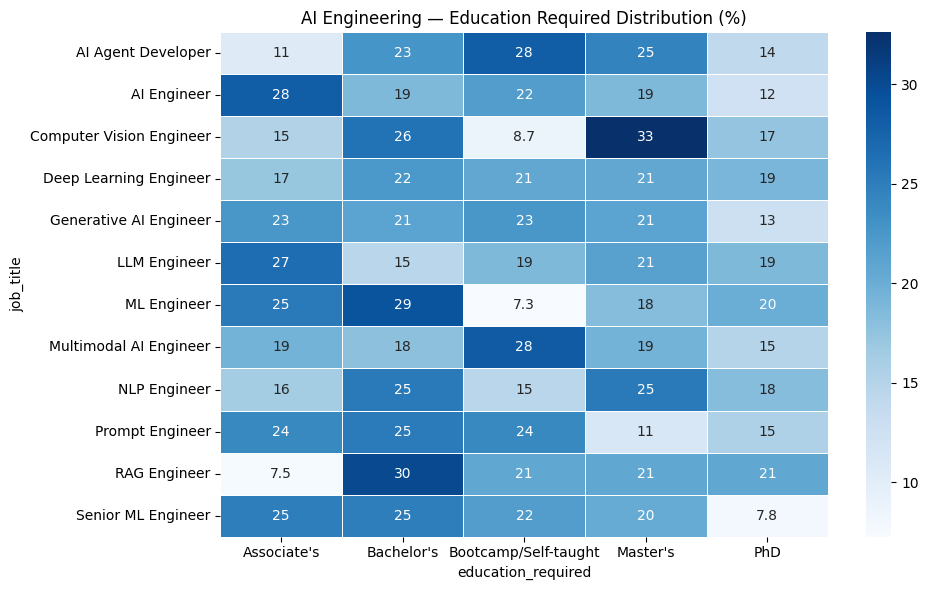

In [19]:
# Education requirements heatmap for AI Engineering roles
ct = (pd.crosstab(temp_df["job_title"], temp_df["education_required"], normalize="index") * 100).round(2)
plt.figure(figsize=(10, 6))
sns.heatmap(ct, annot=True, linewidths=0.5, cmap="Blues")
plt.title("AI Engineering — Education Required Distribution (%)")
plt.tight_layout()
plt.show()

### 4.3 Data Science Deep Dive

In [20]:
temp_df = df[df["job_category"] == "Data Science"]
print("Data Science Job Title Distribution:")
print(temp_df["job_title"].value_counts())
print()
pd.crosstab(temp_df["job_title"], temp_df["is_llm_role"])

Data Science Job Title Distribution:
job_title
Senior Data Scientist    66
Data Scientist           61
Name: count, dtype: int64



is_llm_role,0
job_title,
Data Scientist,61
Senior Data Scientist,66


> **Core Domain Insight:** Market data reveals that traditional Data Scientist tracks stayed strictly focused on statistical modeling and predictive analytics — kept distinct from generative AI branches.

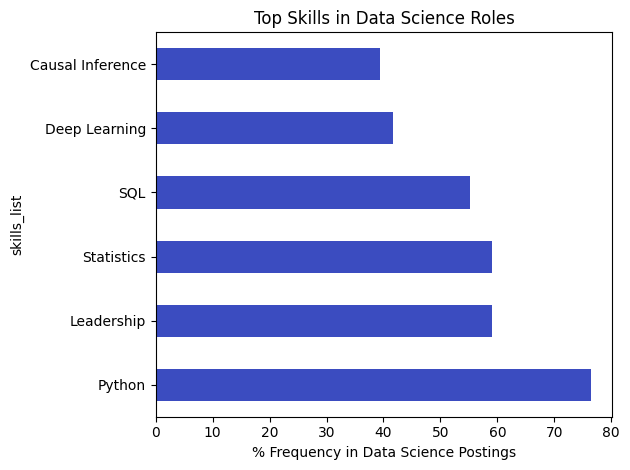

In [21]:
# Top 6 skills in Data Science roles
ct = temp_df["skills_list"].explode().str.strip().value_counts().head(6)
round(ct / len(temp_df) * 100, 2).plot(kind="barh", colormap="coolwarm")
plt.xlabel("% Frequency in Data Science Postings")
plt.title("Top Skills in Data Science Roles")
plt.tight_layout()
plt.show()

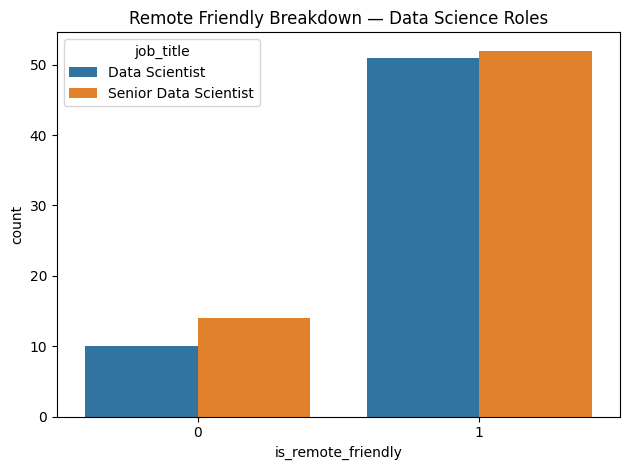

In [22]:
# Remote-friendliness by job title in Data Science
sns.countplot(data=temp_df, x="is_remote_friendly", hue="job_title")
plt.title("Remote Friendly Breakdown — Data Science Roles")
plt.tight_layout()
plt.show()

##### The majority of Data Science roles are remote-friendly.

In [23]:
# Salary by education level × job title
salary_pivot = temp_df.pivot_table(
    index="education_required",
    columns="job_title",
    values="annual_salary_usd",
    aggfunc="mean"
).round(2)
print(salary_pivot)

job_title             Data Scientist  Senior Data Scientist
education_required                                         
Associate's                164944.44              179680.00
Bachelor's                 157727.27              171757.14
Bootcamp/Self-taught       177125.00              190383.33
Master's                   193888.89              202400.00
PhD                        181733.33              200800.00


### 📊 Data Science Education & Salary Insights

- **Degree Tier Progression:** Salaries scale predictably with formal education, peaking at Master's and PhD where Senior Data Scientists break $200k
- **Bootcamp Premium:** Bootcamp/Self-taught professionals outpace Associate's and Bachelor's holders — strong market value for practical skill sets


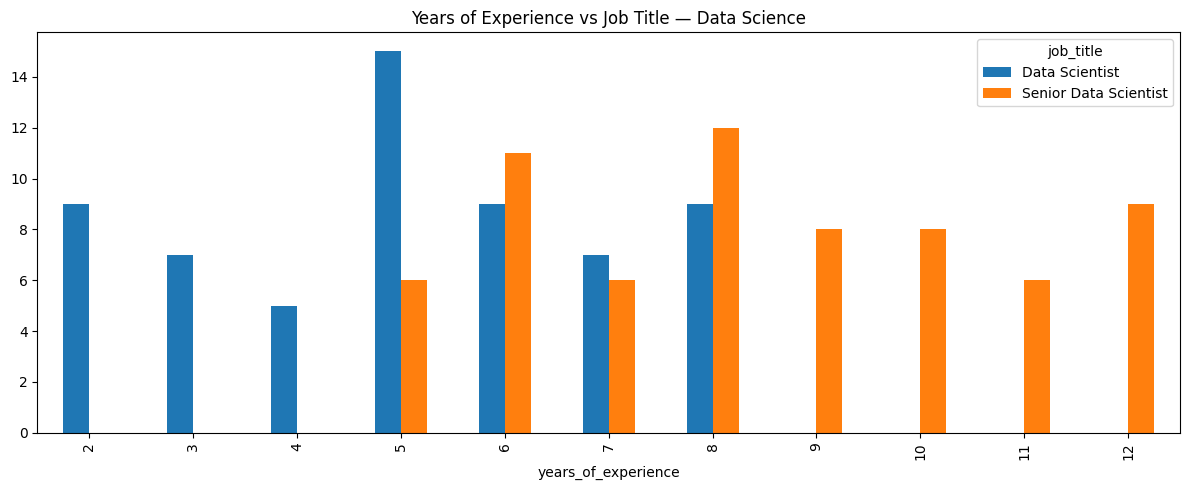

In [24]:
# Experience vs job title transition analysis
z = pd.crosstab(temp_df["years_of_experience"], temp_df["job_title"])
z.plot(kind="bar", figsize=(12, 5))
plt.title("Years of Experience vs Job Title — Data Science")
plt.tight_layout()
plt.show()

### 📊 Promotion Window Insights

- **Transition to Senior:** Data Scientist → Senior Data Scientist primarily happens at **5–6 years** of experience
- **Hard Cutoff:** After **8 years**, the mid-level "Data Scientist" title disappears — Senior is standard for 9+ year professionals


In [25]:
# Market metrics for Data Science
round(temp_df[["ai_salary_premium_pct", "demand_score", "demand_growth_yoy_pct", "benefits_score_10"]].mean(), 2)

ai_salary_premium_pct     6.55
demand_score             90.96
demand_growth_yoy_pct    31.50
benefits_score_10         7.86
dtype: float64

### 📊 Data Science Market Health

- **6.55% AI salary premium** — upskilling in AI directly translates to higher baseline compensation
- **90.96 demand score + 31.50% YoY growth** — aggressive and expanding hiring landscape
- **7.86/10 benefits score** — companies using premium perks to retain AI talent


### 4.4 Job Category × Industry Heatmap

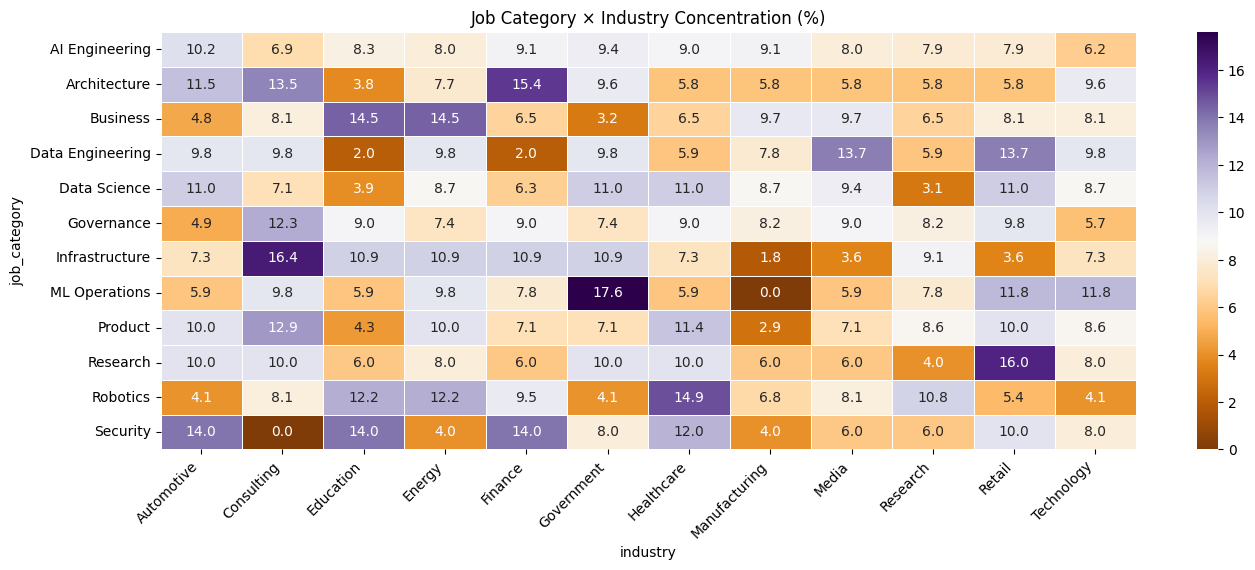

In [26]:
x = round(pd.crosstab(df["job_category"], df["industry"], normalize="index") * 100, 1)
plt.figure(figsize=(14, 6))
sns.heatmap(x, annot=True, fmt=".1f", linewidths=0.5, cmap="PuOr")
plt.title("Job Category × Industry Concentration (%)")
plt.tight_layout()
plt.xticks(rotation=45, ha="right")
plt.show()

### 📊 Key Takeaways — Industry Concentration

- **ML Operations in Government (17.6)** — highest concentration in the dataset; most lucrative intersection
- **Architecture in Finance (15.4)** and **Infrastructure in Consulting (16.4)** — niche but high-paying
- **Research in Retail (16.0)** — surprisingly outperforms many tech-adjacent roles
- **AI Engineering** is relatively consistent (6.2–10.2) across all industries — broad demand, no dominant sector
- **Data Science pays best in Automotive & Government (11.0)**; worst in Research (3.1)
- **For DS/ML job seekers:** Government, Finance, and Consulting offer the highest role-specific salaries


### 4.5 Final Correlation Heatmap with Salary

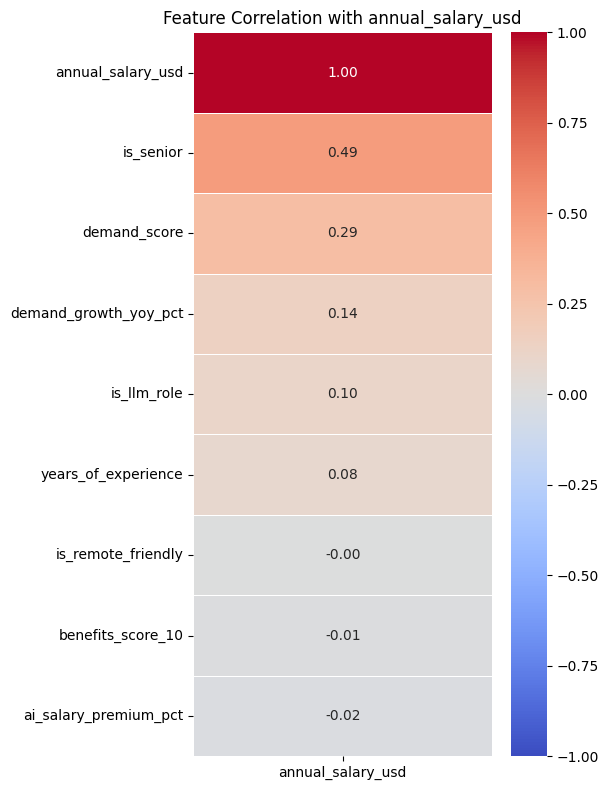

In [27]:
X_drop = ["posting_year", "posting_month", "salary_min_usd", "salary_max_usd"]

corr_series = (
    df.select_dtypes(include='number')
    .drop(columns=X_drop, errors="ignore")
    .corr()["annual_salary_usd"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(6, 8))
sns.heatmap(
    corr_series.to_frame(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title("Feature Correlation with annual_salary_usd")
plt.tight_layout()
plt.show()

---
## Phase 5 — Feature Engineering (`feature_engineer.py`)

This phase replicates the logic from `feature_engineer.py`.

**What it does:**
1. Explodes `required_skills` into individual skill columns (top 93 skills as binary 0/1 flags)
2. Merges skill name variations using regex (e.g. `RAG` and `Rag` → `RAG`)
3. Drops redundant columns
4. Exports `cleaned_data.csv` for the recommender system

> ⚠️ The cleaned CSV is saved to `/kaggle/working/cleaned_data.csv` and used directly in Phase 6.


In [28]:
# ── Feature Engineering Pipeline ──────────────────────────────────────────

# Step 1: Extract top 93 skills (excluding Linux)
df["skills_list"] = df["required_skills"].str.split("|")
skills_exploded_fe = df.explode("skills_list")
skills_exploded_fe["skills_list"] = skills_exploded_fe["skills_list"].str.strip()

top_skills = (
    skills_exploded_fe["skills_list"].value_counts().head(93).index.to_list()
)
if "Linux" in top_skills:
    top_skills.remove("Linux")

print(f"Total skills to encode: {len(top_skills)}")

# Step 2: One-hot encode individual skills
for skill in top_skills:
    df[skill] = df["required_skills"].str.contains(skill, na=False, regex=False).astype(int)

# Step 3: Merge skill name variations via regex
merges = {
    "Cloud":               r"Cloud|Cloud \(AWS/GCP/Azure\)",
    "System_Design":       r"System Design|System_Design",
    "RAG":                 r"RAG|Rag",
    "MLOps":               r"MLOps|Mlops",
    "Fine-Tuning":         r"Fine-tuning|Fine_Tune|LLM Fine-tuning",
    "LLM_APIs":            r"LLM APIs|LLM_APIs|LLM Integration|GenAI APIs",
    "Distributed_Systems": r"Distributed Systems|Distributed_Systems",
    "Prompt_Engineering":  r"Prompt Engineering|Prompt Design",
    "Risk Analysis":       r"Risk Management|Risk Analysis|Risk Assessment",
}

for new_col, pattern in merges.items():
    df[new_col] = df["required_skills"].str.contains(pattern, na=False, regex=True).astype(int)

# Step 4: Drop old/redundant columns
columns_to_drop = [
    "skills_list",
    "Cloud (AWS/GCP/Azure)", "LLM Fine-tuning", "LLM Integration",
    "GenAI APIs", "LLM APIs", "Prompt Design", "Risk Management",
    "Risk Assessment", "System Design", "Distributed Systems",
    "Rag", "Mlops", "Fine_Tune",
]
df = df.drop(columns=columns_to_drop, errors="ignore")

print(f"\n✅ Feature engineering complete! DataFrame shape: {df.shape}")
df.head(2)

Total skills to encode: 92

✅ Feature engineering complete! DataFrame shape: (1500, 112)


,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,country,remote_work,company_size,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier,exp_bin,Python,SQL,Cloud,Leadership,Communication,Research,Agile,Statistics,Problem Solving,PyTorch,Git,Fine-tuning,LLMs,Kubernetes,CUDA,Documentation,APIs,Vector DBs,Docker,Data Visualization,Deep Learning,ML,MLOps,TensorFlow,LangChain,RAG,Data Analysis,Stakeholder Mgmt,Simulation,Product Strategy,AI Literacy,Diffusion Models,NLP,Prompt Engineering,Control Systems,C++,Auditing,Testing,Deployment,EU AI Act,Legal Knowledge,Business Analysis,Computer Vision,Causal Inference,Scikit-learn,Neural Networks,Vision-Language Models,Advanced Statistics,AI Policy,ROS,AutoGen,Risk Analysis,Transformers,Tool Use,Ethics Frameworks,ML Algorithms,Cybersecurity,ML Security,Red Teaming,Planning Systems,Networking,GPU Computing,Hugging Face,Publishing,Search Systems,BERT,Mathematics,Feature Stores,Storage,Text Processing,CNNs,Image Processing,Embeddings,dbt,Airflow,Monitoring,MLflow,CI/CD,OpenCV,ETL,Spark,Enterprise Architecture,System_Design,Fine-Tuning,LLM_APIs,Distributed_Systems,Prompt_Engineering
0,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,USA,On-site,Startup (1-50),Finance,APIs|Planning Systems|Python|Cloud|SQL|Leadership,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k),6-9,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,UK,Hybrid,Enterprise (5000+),Finance,Python|Documentation|LLM APIs|Prompt Design|NLP|Testing|Cloud,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k),0-2,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1


In [31]:
# Export cleaned data for recommender
OUTPUT_PATH = "../data/cleaned_data.csv"
df.to_csv(OUTPUT_PATH, index=False)
print(f"✅ Saved cleaned dataset to: {OUTPUT_PATH}")

✅ Saved cleaned dataset to: ../data/cleaned_data.csv


---
## Phase 6 — Job Recommender System (`model.py`)

This phase replicates the logic from `model.py`.

**How it works:**
1. Load `cleaned_data.csv` (from Phase 5)
2. Build **job skill profiles** — average skill vector per job title (cosine similarity input)
3. Compute a **cosine similarity matrix** across all job title profiles
4. `recommend()` returns: average salary, posting count, top required skills, and similar job titles

> **Why cosine similarity?** It measures the angle between skill vectors, making it robust to titles with different total skill counts — a job requiring 5 skills is fairly compared to one requiring 15.


In [33]:
# ── Load cleaned data ─────────────────────────────────────────────────────
df_clean = pd.read_csv("../data/cleaned_data.csv")
print(f"✅ Cleaned dataset loaded: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")

✅ Cleaned dataset loaded: 1,500 rows × 112 columns


In [34]:
# ── Build job skill profiles ──────────────────────────────────────────────
def build_profiles(df):
    """
    Compute the mean skill vector per job_title.
    Columns from index 26 onward are the binary skill flags created in Phase 5.
    """
    skill_cols = list(df.columns[26:])
    # Keep only numeric binary skill columns
    skill_cols = [c for c in skill_cols if df[c].dtype in ['int64', 'float64', 'int32', 'float32']]
    print(f"Skill columns used for profiles: {len(skill_cols)}")
    job_profiles = df.groupby("job_title")[skill_cols].mean()
    return job_profiles

job_profiles = build_profiles(df_clean)
print(f"\nUnique job titles profiled: {len(job_profiles)}")
job_profiles.head(3)

Skill columns used for profiles: 86

Unique job titles profiled: 25


,SQL,Cloud,Leadership,Communication,Research,Agile,Statistics,Problem Solving,PyTorch,Git,Fine-tuning,LLMs,Kubernetes,CUDA,Documentation,APIs,Vector DBs,Docker,Data Visualization,Deep Learning,ML,MLOps,TensorFlow,LangChain,RAG,Data Analysis,Stakeholder Mgmt,Simulation,Product Strategy,AI Literacy,Diffusion Models,NLP,Prompt Engineering,Control Systems,C++,Auditing,Testing,Deployment,EU AI Act,Legal Knowledge,Business Analysis,Computer Vision,Causal Inference,Scikit-learn,Neural Networks,Vision-Language Models,Advanced Statistics,AI Policy,ROS,AutoGen,Risk Analysis,Transformers,Tool Use,Ethics Frameworks,ML Algorithms,Cybersecurity,ML Security,Red Teaming,Planning Systems,Networking,GPU Computing,Hugging Face,Publishing,Search Systems,BERT,Mathematics,Feature Stores,Storage,Text Processing,CNNs,Image Processing,Embeddings,dbt,Airflow,Monitoring,MLflow,CI/CD,OpenCV,ETL,Spark,Enterprise Architecture,System_Design,Fine-Tuning,LLM_APIs,Distributed_Systems,Prompt_Engineering
job_title,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
AI Agent Developer,0.210526,0.228070,0.105263,0.175439,0.140351,0.192982,0.192982,0.210526,0.0,0.263158,0.0,0.0,0.0,0.0,0.000000,0.77193,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.684211,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.00000,0.00000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.77193,0.000000,0.0,0.77193,0.0,0.0,0.0,0.0,0.0,0.736842,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AI Business Analyst,0.822581,0.225806,0.177419,0.838710,0.209677,0.177419,0.209677,0.258065,0.0,0.209677,0.0,0.0,0.0,0.0,0.000000,0.00000,0.0,0.0,0.693548,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.00000,0.00000,0.83871,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.000000,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AI Compliance Manager,0.227273,0.181818,0.227273,0.090909,0.181818,0.196970,0.121212,0.151515,0.0,0.212121,0.0,0.0,0.0,0.0,0.742424,0.00000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.818182,0.0,0.0,0.80303,0.80303,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.757576,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [35]:
# ── Build cosine similarity matrix ───────────────────────────────────────
def build_sim_matrix(job_profiles):
    """Pairwise cosine similarity across all job title skill vectors."""
    sim_matrix = cosine_similarity(job_profiles)
    return pd.DataFrame(sim_matrix, index=job_profiles.index, columns=job_profiles.index)

sim_df = build_sim_matrix(job_profiles)
print(f"Similarity matrix shape: {sim_df.shape}")
sim_df.head(3)

Similarity matrix shape: (25, 25)


job_title,AI Agent Developer,AI Business Analyst,AI Compliance Manager,AI Engineer,AI Ethics Officer,AI Infrastructure Eng,AI Product Manager,AI Research Scientist,AI Security Engineer,AI Solutions Architect,Computer Vision Engineer,Data Engineer (AI),Data Scientist,Deep Learning Engineer,Generative AI Engineer,LLM Engineer,ML Engineer,MLOps Engineer,Multimodal AI Engineer,NLP Engineer,Prompt Engineer,RAG Engineer,Robotics Engineer (AI),Senior Data Scientist,Senior ML Engineer
job_title,,,,,,,,,,,,,,,,,,,,,,,,,
AI Agent Developer,1.000000,0.200853,0.093146,0.154245,0.167376,0.140230,0.140210,0.127420,0.093449,0.157719,0.096993,0.150262,0.165025,0.102059,0.260243,0.219088,0.141636,0.132305,0.287430,0.110310,0.268024,0.270999,0.117316,0.152429,0.105407
AI Business Analyst,0.200853,1.000000,0.168799,0.252020,0.403672,0.231227,0.213352,0.223852,0.184721,0.271348,0.183341,0.358808,0.532656,0.199143,0.167705,0.178902,0.345512,0.229625,0.181322,0.221907,0.188916,0.197719,0.215395,0.250650,0.196369
AI Compliance Manager,0.093146,0.168799,1.000000,0.131495,0.279918,0.117605,0.124527,0.116182,0.263320,0.161403,0.091455,0.132773,0.144323,0.093680,0.076820,0.075705,0.130631,0.112644,0.090927,0.104688,0.262418,0.100373,0.103528,0.147915,0.097131


In [36]:
# ── Recommender function ─────────────────────────────────────────────────
def recommend(job_title, df, job_profiles, sim_df, top_n_skills=5, top_n_similar=3):
    """
    For a given job_title:
    - Returns avg salary, posting count, top required skills, and similar job titles.
    - Falls back to partial match if exact title not found.
    """
    if job_title not in job_profiles.index:
        matches = [t for t in job_profiles.index if job_title.lower() in t.lower()]
        if matches:
            job_title = matches[0]
            print(f"  ℹ️  Matched to: '{job_title}'")
        else:
            return None

    profile    = job_profiles.loc[job_title]
    top_skills = profile[profile > 0].sort_values(ascending=False).head(top_n_skills)
    similar    = sim_df[job_title].sort_values(ascending=False)
    similar    = similar[similar.index != job_title].head(top_n_similar)
    avg_salary = df[df["job_title"] == job_title]["annual_salary_usd"].mean()
    postings   = len(df[df["job_title"] == job_title])

    return {
        "job_title":    job_title,
        "avg_salary":   avg_salary,
        "postings":     postings,
        "top_skills":   top_skills,
        "similar_jobs": similar,
    }

print("✅ Recommender function defined.")

✅ Recommender function defined.


In [ ]:
# ── Example — Data Scientist ─────────────────────────────────────────────
result = recommend("Data Scientist", df_clean, job_profiles, sim_df)

if result:
    print(f"Job Title   : {result['job_title']}")
    print(f"Avg Salary  : ${result['avg_salary']:,.0f}")
    print(f"Postings    : {result['postings']}")
    print(f"\nTop Skills  :\n{result['top_skills'].round(3)*100}")
    print(f"\nSimilar Jobs (cosine similarity):\n{result['similar_jobs'].round(4).to_string()}")
else:
    print("Job title not found.")

Job Title   : Data Scientist
Avg Salary  : $173,639
Postings    : 61

Top Skills  :
Statistics            83.6
SQL                   82.0
Scikit-learn          80.3
Data Visualization    78.7
ML                    70.5
Name: Data Scientist, dtype: float64

Similar Jobs (cosine similarity):
job_title
AI Business Analyst      0.5327
Senior Data Scientist    0.4469
ML Engineer              0.4333


In [63]:
# ── Example — ML Engineer ────────────────────────────────────────────────
result2 = recommend("ML Engineer", df_clean, job_profiles, sim_df)

if result2:
    print(f"Job Title   : {result2['job_title']}")
    print(f"Avg Salary  : ${result2['avg_salary']:,.0f}")
    print(f"Postings    : {result2['postings']}")
    print(f"\nTop Skills  :\n{result2['top_skills'].round(3)*100}")
    print(f"\nSimilar Jobs (cosine similarity):\n{result2['similar_jobs'].round(4).to_string()}")

Job Title   : ML Engineer
Avg Salary  : $202,582
Postings    : 55

Top Skills  :
SQL           83.6
Kubernetes    81.8
PyTorch       76.4
TensorFlow    74.5
ML            69.1
Name: ML Engineer, dtype: float64

Similar Jobs (cosine similarity):
job_title
Senior ML Engineer        0.5434
Deep Learning Engineer    0.4510
MLOps Engineer            0.4472


In [64]:
# ── Batch test — try multiple titles ─────────────────────────────────────
test_titles = ["LLM Engineer", "AI Agent Developer", "Prompt Engineer", "Data Engineer (AI)"]

print("=" * 60)
for title in test_titles:
    r = recommend(title, df_clean, job_profiles, sim_df, top_n_skills=3, top_n_similar=2)
    if r:
        print(f"\n🔍 {r['job_title']}")
        print(f"   Avg Salary : ${r['avg_salary']:,.0f}")
        print(f"   Postings   : {r['postings']}")
        print(f"   Top Skills : {list(r['top_skills'].index)}")
        print(f"   Similar    : {list(r['similar_jobs'].index)}")
print("=" * 60)


🔍 LLM Engineer
   Avg Salary : $240,960
   Postings   : 75
   Top Skills : ['RAG', 'Fine-Tuning', 'Fine-tuning']
   Similar    : ['Generative AI Engineer', 'Multimodal AI Engineer']

🔍 AI Agent Developer
   Avg Salary : $225,649
   Postings   : 57
   Top Skills : ['AutoGen', 'APIs', 'Tool Use']
   Similar    : ['Multimodal AI Engineer', 'RAG Engineer']

🔍 Prompt Engineer
   Avg Salary : $151,451
   Postings   : 71
   Top Skills : ['Documentation', 'NLP', 'Testing']
   Similar    : ['LLM Engineer', 'Generative AI Engineer']

🔍 Data Engineer (AI)
   Avg Salary : $176,157
   Postings   : 51
   Top Skills : ['SQL', 'Feature Stores', 'dbt']
   Similar    : ['AI Business Analyst', 'Data Scientist']


---
## 🏁 Project Summary

| Phase | Output |
|---|---|
| EDA | Data quality verified, salary distributions, correlation analysis |
| Hypothesis Testing | 4 hypotheses tested, confirmed via charts |
| AI Engineering Analysis | Salary heatmap, demand/growth/benefits matrix, education breakdown |
| Data Science Analysis | Skill demand, remote analysis, education-salary pivot, promotion window |
| Feature Engineering | 90+ binary skill columns, variant merges, `cleaned_data.csv` |
| Recommender System | Cosine similarity on skill profiles → avg salary + similar job titles |

### 🔑 Final Key Insights
1. `experience_level` (job tier) is the **strongest salary predictor** — negotiate title, not years
2. **Python + Cloud + System Design** = the highest value skill combination in the market
3. **Specialized/rare skills pay more than common skills** — scarcity beats frequency
4. **Remote work does not affect salary** — take the flexibility
5. **The recommender reveals skill overlap** — Data Scientists and ML Engineers share ~70%+ skill profiles

---
*Built by Muhammad Zain | AI Engineering Student, COMSATS University Lahore*  
*Dataset: AI Jobs Market 2025–2026*
